In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

from svm_primal import PrimalSVM
from svm_dual import DualSVM
from kernels import linear_kernel, make_rbf_kernel, make_polynomial_kernel, make_laplacian_kernel
from utils import *

try:
	import scienceplots
	plt.style.use('science')
except ImportError:
    print("scienceplots not found, using default matplotlib style.")
    plt.style.use('default')

In [2]:
# Example usage for both models (uses test_linear function)
X, y = make_toy_data(n=100, random_state=42)

Training Primal SVM (linear)...
Iter 0, Obj=100.0000, GradNorm=194.9760, lr=0.0010, w=[0.1295 0.1457], b=0.00000000, grad_w=[-129.5117 -145.7476], grad_b=0.0000
Iter 1000, Obj=0.5004, GradNorm=1.3970, lr=0.0010, w=[0.7102 0.7036], b=-0.00300000, grad_w=[-0.69    0.6895], grad_b=-1.0000
Iter 2000, Obj=0.5006, GradNorm=1.4014, lr=0.0010, w=[0.7081 0.7058], b=-0.00300000, grad_w=[ 0.6941 -0.6944], grad_b=1.0000
Iter 3000, Obj=0.5012, GradNorm=1.3990, lr=0.0010, w=[0.7083 0.7058], b=-0.00100000, grad_w=[-0.6919  0.6918], grad_b=-1.0000
Iter 4000, Obj=0.5018, GradNorm=1.4009, lr=0.0010, w=[0.7076 0.7064], b=-0.00100000, grad_w=[ 0.6936 -0.6938], grad_b=1.0000
Iter 5000, Obj=0.5010, GradNorm=1.4003, lr=0.0010, w=[0.7071 0.7071], b=-0.00100000, grad_w=[ 0.6931 -0.6931], grad_b=1.0000
Iter 6000, Obj=0.5007, GradNorm=1.4001, lr=0.0010, w=[0.7069 0.7073], b=-0.00100000, grad_w=[ 0.6929 -0.6929], grad_b=1.0000
Iter 7000, Obj=0.5005, GradNorm=1.4000, lr=0.0010, w=[0.7068 0.7074], b=-0.00100000, gr

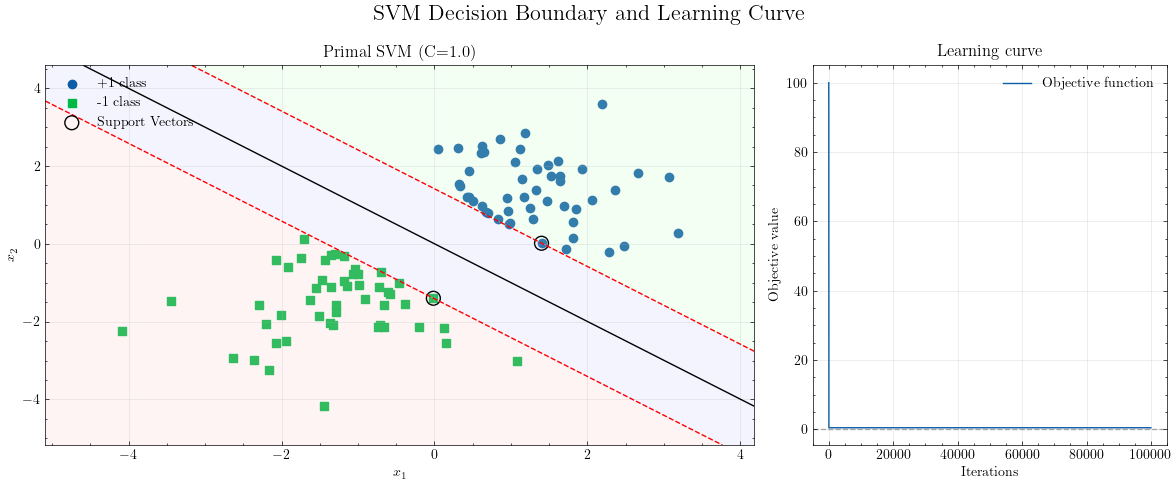

b: -0.0010000000000000009, w: [0.70676041 0.70745316]
Margin: [3.38329523 2.45065894 1.07814038 2.0886237  2.23095324 1.31460457
 2.24606438 2.22674518 0.99852034 1.68433683 1.70660804 1.64105197
 1.87766314 2.38989608 2.13366131 1.27900912 1.35313912 2.31413358
 1.2834337  1.12875959 2.50744442 2.64403821 1.043482   2.5074187
 1.04880004 1.81994873 2.31319695 1.1417462  2.71558672 1.93362807
 2.29094419 1.5299071  1.50264301 4.08189512 2.8501814  1.37864005
 1.13951459 1.96724815 3.15848382 1.17021393 1.12212587 1.91409925
 1.04467577 2.48726295 2.63992958 1.6721637  1.98300306 1.4612098
 1.75334127 1.02765337 1.58227436 3.78586895 1.12729394 1.98389226
 1.75076796 1.76548991 3.13473153 1.30391526 2.41872039 2.01994894
 3.82484543 2.40496899 2.04596098 1.57341951 4.47640066 1.44590268
 1.19857018 1.15125636 1.68617576 1.29160825 1.00147966 1.65080492
 2.15523838 1.03562436 1.43968598 3.02664804 3.97100352 1.06109369
 1.64705837 3.47531228 2.37788558 1.30290996 2.71286239 1.36332614
 1

In [3]:
# Linear SVM - primal formulation
print("Training Primal SVM (linear)...")
primal_model = PrimalSVM(C=1.00, max_iter=100_000, tol=1e-12, lr=1e-3, bb_steps=True, verbose=True)
primal_model.fit(X, y)
primal_accuracy = primal_model.score(X, y)
print(f"Primal SVM accuracy: {primal_accuracy:.4f}")
plot_decision_boundary_2D(primal_model, X, y, title=f"Primal SVM (C={primal_model.C})",save_path="../figures/primal_svm.png")

primal_model.get_support_vectors()
print(f"Number of support vectors: {len(primal_model.get_support_vectors())}")
print(f"Support vectors: {primal_model.get_support_vectors()}")
primal_model.b
print(f"Number of X: {len(X)}")


Training Dual SVM (linear)...
Iter=0, Obj=-0.131525, Step=0.00263, ||alpha_diff||=2.630e-02
Iter=50, Obj=-0.490844, Step=0.262, ||alpha_diff||=9.526e-03
Iter=100, Obj=-0.500000, Step=0.01, ||alpha_diff||=1.298e-12
Iter=150, Obj=-0.500000, Step=0.01, ||alpha_diff||=1.298e-12
Iter=200, Obj=-0.500000, Step=0.01, ||alpha_diff||=1.299e-12
Iter=250, Obj=-0.500000, Step=0.01, ||alpha_diff||=1.299e-12
Iter=300, Obj=-0.500000, Step=0.01, ||alpha_diff||=1.299e-12
Iter=350, Obj=-0.500000, Step=0.01, ||alpha_diff||=1.299e-12
Iter=400, Obj=-0.500000, Step=0.01, ||alpha_diff||=1.299e-12
Iter=450, Obj=-0.500000, Step=0.01, ||alpha_diff||=1.299e-12
Iter=500, Obj=-0.500000, Step=0.01, ||alpha_diff||=1.299e-12
Iter=550, Obj=-0.500000, Step=0.01, ||alpha_diff||=1.299e-12
Iter=600, Obj=-0.500000, Step=0.01, ||alpha_diff||=1.299e-12
Iter=650, Obj=-0.500000, Step=0.01, ||alpha_diff||=1.299e-12
Iter=700, Obj=-0.500000, Step=0.01, ||alpha_diff||=1.299e-12
Iter=750, Obj=-0.500000, Step=0.01, ||alpha_diff||=1.

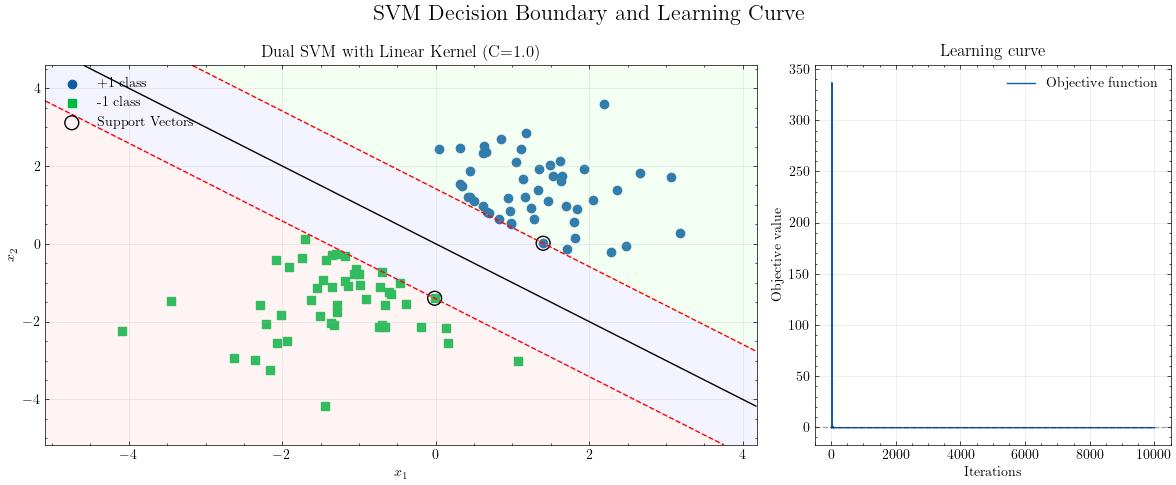

array([0.70710678, 0.70710678])

In [4]:
# Linear SVM - dual formulation
print("\nTraining Dual SVM (linear)...")
dual_model = DualSVM(C=1.0, max_iter=10_000, tol=1e-12, use_line_search = True, bb_steps=True, verbose=True)
dual_model.fit(X, y)
dual_accuracy = dual_model.score(X, y)
print(f"Dual SVM accuracy: {dual_accuracy:.4f}")
plot_decision_boundary_2D(dual_model, X, y, title=f"Dual SVM with Linear Kernel (C={dual_model.C})",save_path="../figures/dual_svm.png")
dual_model.recover_w()


Training Dual SVM (RBF kernel)...
Iter=0, Obj=-0.891969, Step=0.04628, ||alpha_diff||=1.000e-01
Iter=50, Obj=-4.603154, Step=1.119, ||alpha_diff||=2.612e-01
Iter=100, Obj=-4.632798, Step=0.301, ||alpha_diff||=4.517e-03
Iter=150, Obj=-4.633151, Step=5.517, ||alpha_diff||=1.138e-03
Iter=200, Obj=-4.633157, Step=0.3783, ||alpha_diff||=3.802e-05
Iter=250, Obj=-4.633157, Step=0.01, ||alpha_diff||=3.671e-08
Iter=300, Obj=-4.633157, Step=0.01, ||alpha_diff||=3.618e-08
Iter=350, Obj=-4.633157, Step=0.01, ||alpha_diff||=3.565e-08
Iter=400, Obj=-4.633157, Step=0.01, ||alpha_diff||=3.513e-08
Iter=450, Obj=-4.633157, Step=0.01, ||alpha_diff||=3.462e-08
Iter=500, Obj=-4.633157, Step=0.01, ||alpha_diff||=3.411e-08
Iter=550, Obj=-4.633157, Step=0.01, ||alpha_diff||=3.362e-08
Iter=600, Obj=-4.633157, Step=0.01, ||alpha_diff||=3.313e-08
Iter=650, Obj=-4.633157, Step=0.01, ||alpha_diff||=3.264e-08
Iter=700, Obj=-4.633157, Step=0.01, ||alpha_diff||=3.217e-08
Iter=750, Obj=-4.633157, Step=0.01, ||alpha_d

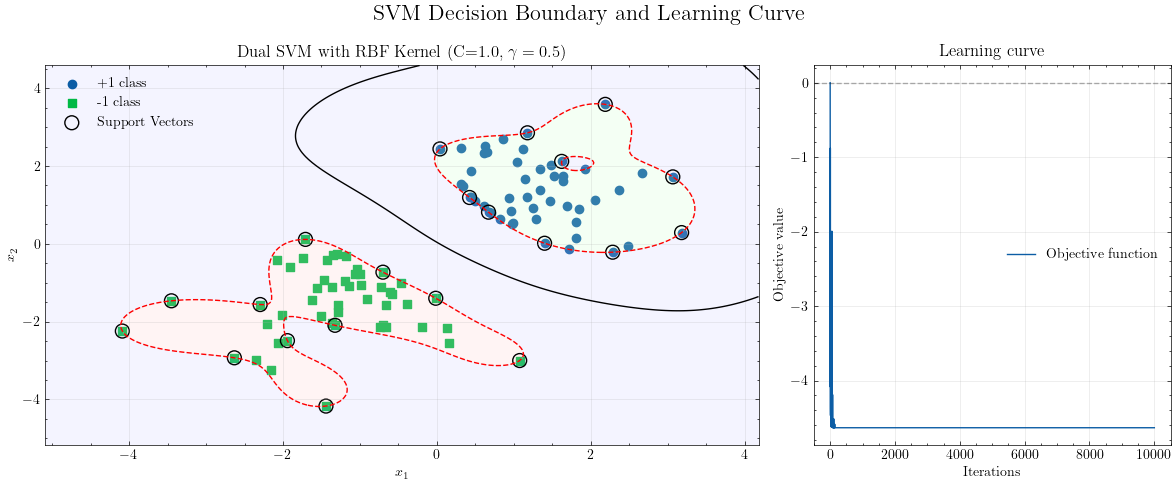

In [5]:

# Now try with an RBF kernel (non-linear)
print("\nTraining Dual SVM (RBF kernel)...")
rbf_kernel = make_rbf_kernel(gamma=0.5)
rbf_model = DualSVM(C=1.0, max_iter=10_000, tol=1e-12, kernel=rbf_kernel, use_line_search = True, bb_steps=True, verbose=True)
rbf_model.fit(X, y)
rbf_accuracy = rbf_model.score(X, y)
print(f"RBF Kernel SVM accuracy: {rbf_accuracy:.4f}")
plot_decision_boundary_2D(rbf_model, X, y, title=f"Dual SVM with RBF Kernel (C={rbf_model.C}, $\\gamma=0.5$)",save_path="../figures/dual_svm_rbf.png")

Iter 0, Obj=10.0000, GradNorm=19.4976, lr=0.0010, w=[0.013  0.0146], b=0.00000000, grad_w=[-12.9512 -14.5748], grad_b=0.0000
Iter 1000, Obj=0.4650, GradNorm=0.0868, lr=0.0010, w=[0.6735 0.6063], b=0.03750000, grad_w=[0.0779 0.0382], grad_b=0.0000
Iter 2000, Obj=0.4649, GradNorm=0.1120, lr=0.0010, w=[0.6758 0.5995], b=0.03870000, grad_w=[-0.0502  0.005 ], grad_b=0.1000
Iter 3000, Obj=0.4649, GradNorm=0.0860, lr=0.0010, w=[0.6766 0.597 ], b=0.03910000, grad_w=[0.081  0.0289], grad_b=0.0000
Iter 4000, Obj=0.4649, GradNorm=0.1547, lr=0.0010, w=[0.677 0.596], b=0.03930000, grad_w=[-0.1469 -0.0486], grad_b=0.0000
Iter 5000, Obj=0.4649, GradNorm=0.0860, lr=0.0010, w=[0.677  0.5956], b=0.03940000, grad_w=[0.0814 0.0275], grad_b=0.0000
Iter 6000, Obj=0.4649, GradNorm=0.1547, lr=0.0010, w=[0.6772 0.5955], b=0.03940000, grad_w=[-0.1467 -0.0491], grad_b=0.0000
Iter 7000, Obj=0.4649, GradNorm=0.1113, lr=0.0010, w=[0.6772 0.5955], b=0.03940000, grad_w=[-0.0488  0.0009], grad_b=0.1000
Iter 8000, Obj=

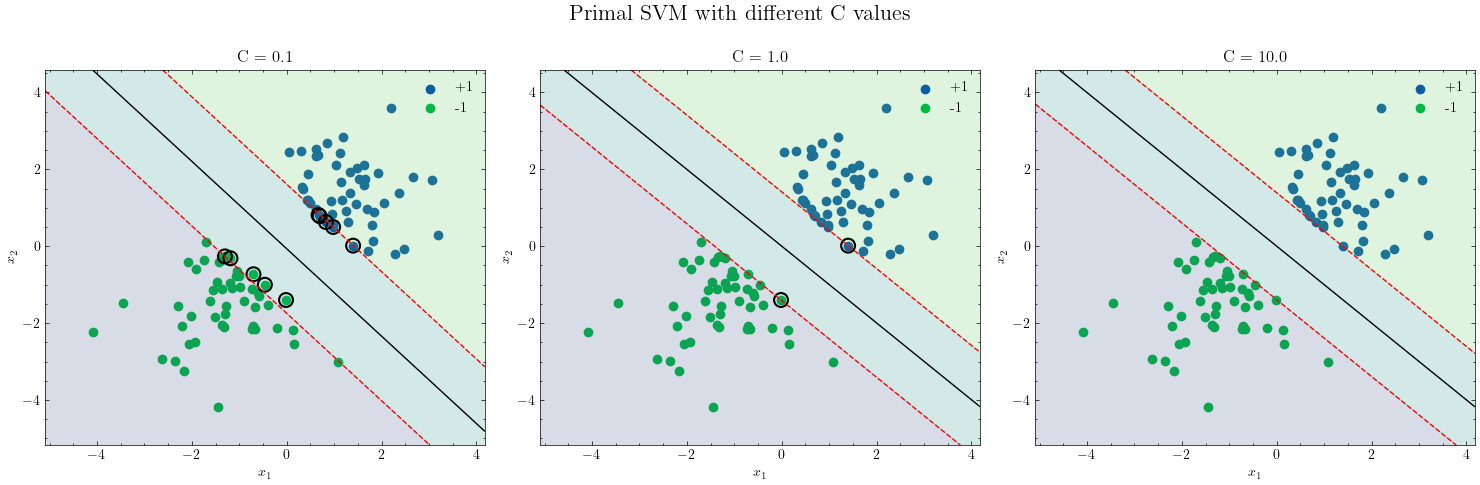

In [13]:
# Let's compare with different C values
C_values = [0.1, 1.0, 10.0]
plt.figure(figsize=(15, 5))

for i, C in enumerate(C_values):
    
    model = PrimalSVM(C=C, max_iter=100_000, tol=1e-12, lr=1e-3, bb_steps=True, verbose=True)
    model.fit(X, y)
    plt.subplot(1, 3, i+1)
    plt.title(f"C = {C}")
    
    # Class scatter plot
    plt.scatter(X[y==+1,0], X[y==+1,1], label="+1")
    plt.scatter(X[y==-1,0], X[y==-1,1], label="-1")
    
    # Create mesh and predict
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    XX, YY = np.meshgrid(np.linspace(x_min, x_max, 100),
                       np.linspace(y_min, y_max, 100))
    Z = model.decision_function(np.c_[XX.ravel(), YY.ravel()])
    Z = Z.reshape(XX.shape)
    
    # Plot decision boundary and margins
    plt.contour(XX, YY, Z, levels=[-1, 0, 1], colors=['r', 'k', 'r'], 
               linestyles=['--', '-', '--'])
    plt.contourf(XX, YY, Z, levels=[-1e9, -1, 1, 1e9], alpha=0.2)
    
    # Show support vectors
    sv_indices = model.get_support_vectors()
    if len(sv_indices) > 0:
        plt.scatter(X[sv_indices, 0], X[sv_indices, 1], s=100, 
                   facecolors='none', edgecolors='k', linewidths=1.5)
    
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.legend()

plt.tight_layout()
plt.suptitle("Primal SVM with different C values", fontsize=16)
plt.subplots_adjust(top=0.85)
plt.savefig("../figures/primal_svm_c_values.png", dpi=300)
plt.show()

Iter=0, Obj=-0.186426, Step=0.001398, ||alpha_diff||=2.283e-02
Iter=50, Obj=-11.618782, Step=0.01633, ||alpha_diff||=8.890e-02
Iter=100, Obj=-18.761821, Step=0.7034, ||alpha_diff||=2.545e-01
Iter=150, Obj=-18.957383, Step=2.254, ||alpha_diff||=4.257e-01
Iter=0, Obj=-1.769390, Step=0.01486, ||alpha_diff||=1.633e-01
Iter=50, Obj=21.938482, Step=0.1685, ||alpha_diff||=6.366e+00
Iter=100, Obj=-16.684148, Step=0.1491, ||alpha_diff||=4.223e-02
Iter=150, Obj=-16.688226, Step=3.11, ||alpha_diff||=3.016e-01
Iter=200, Obj=-16.702085, Step=0.9241, ||alpha_diff||=5.778e-06
Iter=250, Obj=-16.702085, Step=0.01, ||alpha_diff||=2.810e-08
Iter=300, Obj=-16.702085, Step=0.01, ||alpha_diff||=2.727e-08
Iter=350, Obj=-16.702085, Step=0.01, ||alpha_diff||=2.647e-08
Iter=400, Obj=-16.702085, Step=0.01, ||alpha_diff||=2.570e-08
Iter=450, Obj=-16.702085, Step=0.01, ||alpha_diff||=2.495e-08
Iter=500, Obj=-16.702085, Step=0.01, ||alpha_diff||=2.424e-08
Iter=550, Obj=-16.702085, Step=0.01, ||alpha_diff||=2.355e-0

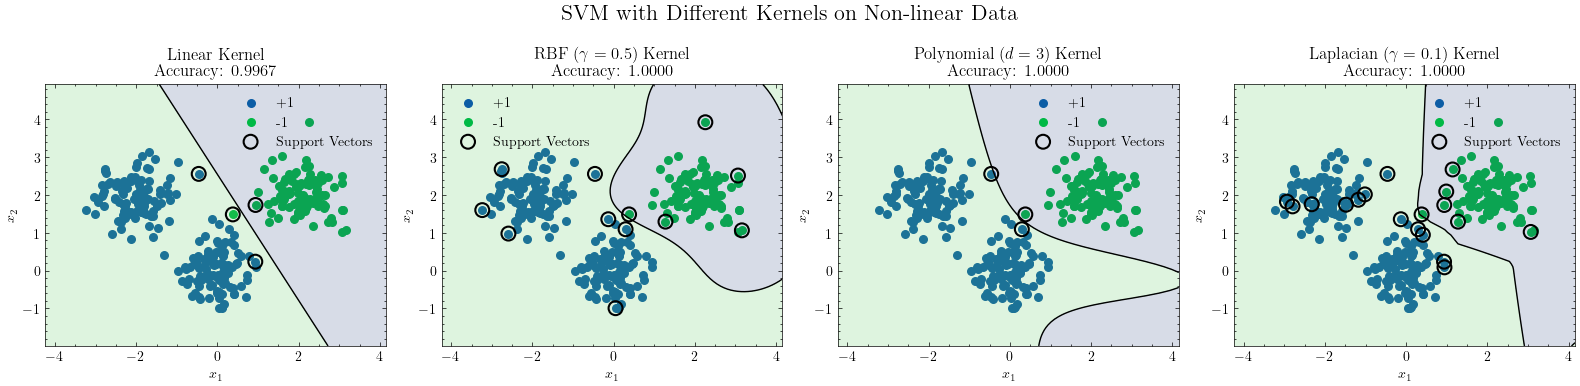

In [12]:
# Compare different kernels on a non-linear dataset
X_nl, y_nl = make_nonlinear_data(n=100, random_state=42)

# Create and compare models with different kernels
kernels = {
    "Linear": linear_kernel,
    "RBF ($\\gamma=0.5$)": make_rbf_kernel(gamma=0.5),
    "Polynomial ($d=3$)": make_polynomial_kernel(degree=3, coef0=0.1), 
    "Laplacian ($\\gamma=0.1$)": make_laplacian_kernel(gamma=0.1)
}

plt.figure(figsize=(16, 4))
for i, (name, kernel) in enumerate(kernels.items()):
    model = DualSVM(C=10.0, kernel=kernel, max_iter=10_000, tol=1e-12, use_line_search = True, bb_steps=True, verbose=True)
    model.fit(X_nl, y_nl)
    acc = model.score(X_nl, y_nl)
    
    plt.subplot(1, 4, i+1)
    plt.title(f"{name} Kernel\nAccuracy: {acc:.4f}")
    
    # Plot data points
    plt.scatter(X_nl[y_nl==+1,0], X_nl[y_nl==+1,1], label="+1", s=30)
    plt.scatter(X_nl[y_nl==-1,0], X_nl[y_nl==-1,1], label="-1", s=30)
    
    # Create mesh and predict
    x_min, x_max = X_nl[:,0].min()-1, X_nl[:,0].max()+1
    y_min, y_max = X_nl[:,1].min()-1, X_nl[:,1].max()+1
    XX, YY = np.meshgrid(np.linspace(x_min, x_max, 100),
                       np.linspace(y_min, y_max, 100))
    Z = model.decision_function(np.c_[XX.ravel(), YY.ravel()])
    Z = Z.reshape(XX.shape)
    
    # Plot decision boundary
    plt.contour(XX, YY, Z, levels=[0], colors='k')
    plt.contourf(XX, YY, Z, levels=[-1e9, 0, 1e9], alpha=0.2)
    
    # Show support vectors
    sv_indices = model.get_support_vectors()
    if len(sv_indices) > 0:
        plt.scatter(X_nl[sv_indices, 0], X_nl[sv_indices, 1], s=100, 
                   facecolors='none', edgecolors='k', linewidths=1.5,
                   label="Support Vectors")
    
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.legend()

plt.suptitle("SVM with Different Kernels on Non-linear Data", fontsize=16)
plt.subplots_adjust(top=0.85)
plt.savefig("../figures/svm_kernels_comparison.png", dpi=300)
plt.tight_layout()
plt.show()

Dataset shape: (569, 30)
Number of features: 30
Class distribution: [212 357]

Results on Breast Cancer dataset:
------------------------------------------------------------
Kernel          | C     | Train Accuracy  | Test Accuracy  
------------------------------------------------------------
Linear          | 0.1   | 0.9824          | 0.9825         
Linear          | 1.0   | 0.9868          | 0.9561         
Linear          | 10.0  | 0.9912          | 0.9649         
RBF (gamma=0.01) | 0.1   | 0.9516          | 0.9649         
RBF (gamma=0.01) | 1.0   | 0.9758          | 0.9649         
RBF (gamma=0.01) | 10.0  | 0.9912          | 0.9825         
Poly (d=2)      | 0.1   | 0.9824          | 0.8860         
Poly (d=2)      | 1.0   | 0.9758          | 0.8860         
Poly (d=2)      | 10.0  | 0.9890          | 0.9211         
Lapl (gamma=0.1) | 0.1   | 0.9538          | 0.9561         
Lapl (gamma=0.1) | 1.0   | 0.9934          | 0.9649         
Lapl (gamma=0.1) | 10.0  | 1.0000       

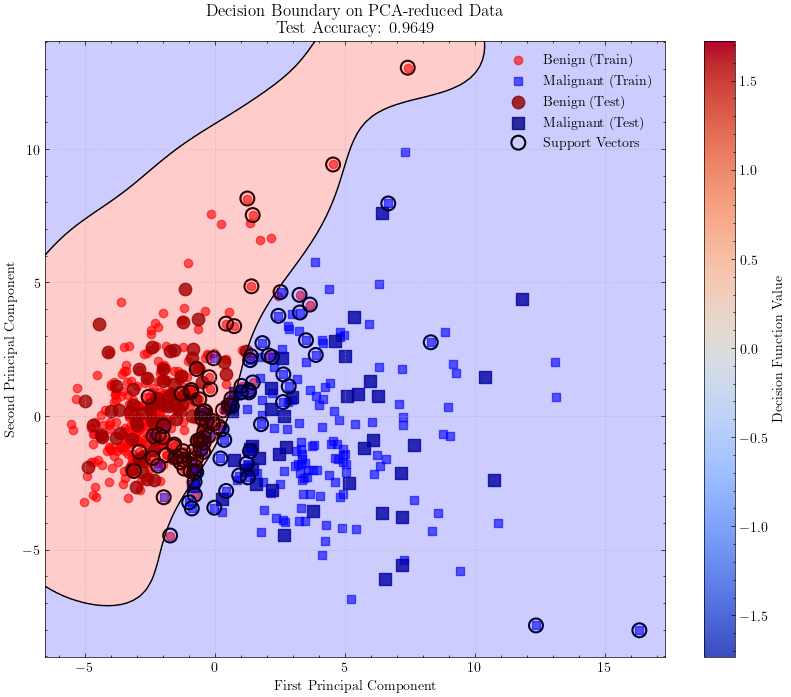


Feature importance (PCA components):
Principal Component 1 (Explains 43.25% of variance)
  mean concavity: 0.2580
  mean concave points: 0.2565
  worst concave points: 0.2491
  mean compactness: 0.2385
  worst perimeter: 0.2320
Principal Component 2 (Explains 19.73% of variance)
  mean fractal dimension: 0.3623
  fractal dimension error: 0.2959
  worst fractal dimension: 0.2666
  compactness error: 0.2455
  mean radius: -0.2399


In [14]:
# Let's also test a real dataset from scikit-learn
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load and preprocess breast cancer dataset
cancer = load_breast_cancer()
X_cancer = cancer.data
y_cancer = 2 * cancer.target - 1  # Convert to {-1, 1}

# Scale features
scaler = StandardScaler()
X_cancer = scaler.fit_transform(X_cancer)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42
)

print(f"Dataset shape: {X_cancer.shape}")
print(f"Number of features: {X_cancer.shape[1]}")
print(f"Class distribution: {np.bincount(cancer.target)}")

# Try different kernels on this real dataset
kernels = {
    "Linear": linear_kernel,
    "RBF (gamma=0.01)": make_rbf_kernel(gamma=0.01),
    "Poly (d=2)": make_polynomial_kernel(degree=2, coef0=0.01),
    "Lapl (gamma=0.1)": make_laplacian_kernel(gamma=0.1)
}

# Create a results table
print("\nResults on Breast Cancer dataset:")
print("-" * 60)
print(f"{'Kernel':<15} | {'C':<5} | {'Train Accuracy':<15} | {'Test Accuracy':<15}")
print("-" * 60)

for name, kernel in kernels.items():
    for C in [0.1, 1.0, 10.0]:
        model = DualSVM(C=C, kernel=kernel, max_iter=10_000, tol=1e-12, use_line_search = True, bb_steps=True, verbose=False)
        model.fit(X_train, y_train)
        
        train_acc = model.score(X_train, y_train)
        test_acc = model.score(X_test, y_test)
        
        print(f"{name:<15} | {C:<5.1f} | {train_acc:<15.4f} | {test_acc:<15.4f}")

print("-" * 60)

# Plot decision boundary for the best performing model using PCA for visualization
from sklearn.decomposition import PCA

# Train the best model on the full dataset
best_model = DualSVM(C=1.0, kernel=make_rbf_kernel(gamma=0.01), max_iter=1000)
best_model.fit(X_train, y_train)

# Use PCA to reduce the data to 2D for visualization
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

# Create a figure
plt.figure(figsize=(10, 8))
plt.title(f"PCA Visualization of Breast Cancer Dataset\nRBF Kernel ($\\gamma=0.01$), $C=1.0$, Test Accuracy: {best_model.score(X_test, y_test):.4f}")

# Plot the data points
plt.scatter(X_train_2d[y_train==+1, 0], X_train_2d[y_train==+1, 1], c='r', marker='o', alpha=0.6, label="Benign (Train)")
plt.scatter(X_train_2d[y_train==-1, 0], X_train_2d[y_train==-1, 1], c='b', marker='s', alpha=0.6, label="Malignant (Train)")
plt.scatter(X_test_2d[y_test==+1, 0], X_test_2d[y_test==+1, 1], c='darkred', marker='o', alpha=0.8, s=80, label="Benign (Test)")
plt.scatter(X_test_2d[y_test==-1, 0], X_test_2d[y_test==-1, 1], c='darkblue', marker='s', alpha=0.8, s=80, label="Malignant (Test)")

# Get support vectors in original space and project to 2D
sv_indices = best_model.get_support_vectors()
if len(sv_indices) > 0:
    plt.scatter(X_train_2d[sv_indices, 0], X_train_2d[sv_indices, 1], s=100, 
               facecolors='none', edgecolors='k', linewidths=1.5,
               label="Support Vectors")

# Create a mesh grid for the decision boundary
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                    np.linspace(y_min, y_max, 100))

# This is a workaround as we can't directly visualize the decision boundary in 2D PCA space
# We'll train a new SVM model on the 2D PCA data just for visualization
viz_model = DualSVM(C=1.0, kernel=make_rbf_kernel(gamma=0.1), max_iter=1000)
viz_model.fit(X_train_2d, y_train)
Z = viz_model.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.contour(xx, yy, Z, levels=[0], colors='k')
contourf = plt.contourf(xx, yy, Z, levels=[-1e9, 0, 1e9], alpha=0.2, colors=['blue', 'red'])

plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.5)

# Create a properly initialized ScalarMappable for the colorbar
norm = plt.Normalize(vmin=Z.min(), vmax=Z.max())
sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm, norm=norm)
sm.set_array([])  # You need to set an array for the ScalarMappable
plt.gcf().colorbar(sm, ax=plt.gca(), label='Decision Function Value')
plt.title(f"Decision Boundary on PCA-reduced Data\nTest Accuracy: {best_model.score(X_test, y_test):.4f}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("../figures/breast_cancer_pca.png", dpi=300)
plt.show()

# Print feature importance based on PCA
print("\nFeature importance (PCA components):")
feature_names = cancer.feature_names
for i, (eigen_val, eigen_vec) in enumerate(zip(pca.explained_variance_ratio_, pca.components_)):
    if i < 2:  # Only show first two components
        print(f"Principal Component {i+1} (Explains {eigen_val*100:.2f}% of variance)")
        # Get the top 5 features contributing to this component
        indices = np.argsort(np.abs(eigen_vec))[-5:][::-1]
        for idx in indices:
            print(f"  {feature_names[idx]}: {eigen_vec[idx]:.4f}")